In [64]:
from __future__ import print_function, division
import sys,os
import numpy as np # type: ignore
import matplotlib.pyplot as plt # type: ignore
%matplotlib inline 
font = {
        'weight' : 'bold',
        'size'   : 16}
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', **font) 

figures_path = "../figs"
model = "EHM_Itensor" 
exec = "Phase_Diagram"
results = "../results"

U_max = 6.0
V_max = 4.0

U_min = -U_max
V_min = -V_max

N_Points = 50
L = 5
'''
        L = 6 e 7 
        N_Points = 100

        L = 5 e 6 
        N_Points = 50
'''

'\n        L = 6 e 7 \n        N_Points = 100\n\n        L = 5 e 6 \n        N_Points = 50\n'

In [65]:
def load_data(L, U_max, V_max, N_Points, U_min = -U_max, V_min = -V_max, min_vals = False):
    
    # Generate discretized U and V values
    U_vals = np.loadtxt(f"{results}/{model}_{exec}/U_vals_NPoints={N_Points}.txt")
    V_vals = np.loadtxt(f"{results}/{model}_{exec}/V_vals_NPoints={N_Points}.txt")

    U_vals = np.array(U_vals)
    V_vals = np.array(V_vals)

    magnetization = np.zeros((N_Points, N_Points, L))
    charge_density = np.zeros((N_Points, N_Points, L))
    doublons = np.zeros((N_Points, N_Points, L))

    energy = np.zeros((N_Points, N_Points))
    E_p = np.zeros((N_Points, N_Points))

    single_site_entanglment = np.zeros((N_Points, N_Points))
    quantum_coh  = np.zeros((N_Points, N_Points))

    # Loop over U and V values
    for i, U_f in enumerate(U_vals):
        for j, V_f in enumerate(V_vals):
            info_output = f"{results}/{model}_{exec}/XXXXX_{model}_L={L}_U={U_f}_V={V_f}_NPoints={N_Points}.txt"

            str_magnetization = info_output.replace('XXXXX', 'magnetization')
            str_charge_density = info_output.replace('XXXXX', 'charge_density')
            str_doublons = info_output.replace('XXXXX', 'doublons')

            magnetization[i, j] = np.loadtxt(str_magnetization)
            charge_density[i, j] = np.loadtxt(str_charge_density)
            doublons[i, j] = np.loadtxt(str_doublons)

            str_energy = info_output.replace('XXXXX', 'E_GS')
            energy[i, j] = np.loadtxt(str_energy)

            E_p_str = info_output.replace('XXXXX', 'E_p')
            E_p[i, j] = np.loadtxt(E_p_str)

            S_str = info_output.replace('XXXXX', 'S')
            single_site_entanglment[i, j] = np.loadtxt(S_str)

            quantum_coh_str = info_output.replace('XXXXX', 'Coh')
            quantum_coh[i, j] = np.loadtxt(quantum_coh_str)

    return magnetization, charge_density, doublons, energy, E_p, single_site_entanglment, quantum_coh, U_vals, V_vals

In [66]:
def m_SDW(L, Sj): 
    m_sdw = 0
    for j in range(L):
        m_sdw += (-1)**(j) * (Sj[j])
    return m_sdw / L

def m_CDW(L, nj):
    m_cdw = 0
    for j in range(L):
        m_cdw += (-1)**(j) * (nj[j] - 1)
    return m_cdw / L 

In [67]:
magnetization, charge_density, doublons, energy, E_p, avg_linear_entropy, quantum_coh, U_vals, V_vals =  load_data(L, U_max, V_max, N_Points, min_vals=False)

In [68]:
print(quantum_coh.shape)

(50, 50)


/tmp/ipykernel_49598/3537086168.py:28: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ax[0].contour(X, Y, m_sdw, colors='white', linestyle='--', linewidths=0.7)
/tmp/ipykernel_49598/3537086168.py:39: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ax[1].contour(X, Y, m_cdw, colors='white', linestyle='--', linewidths=0.7)


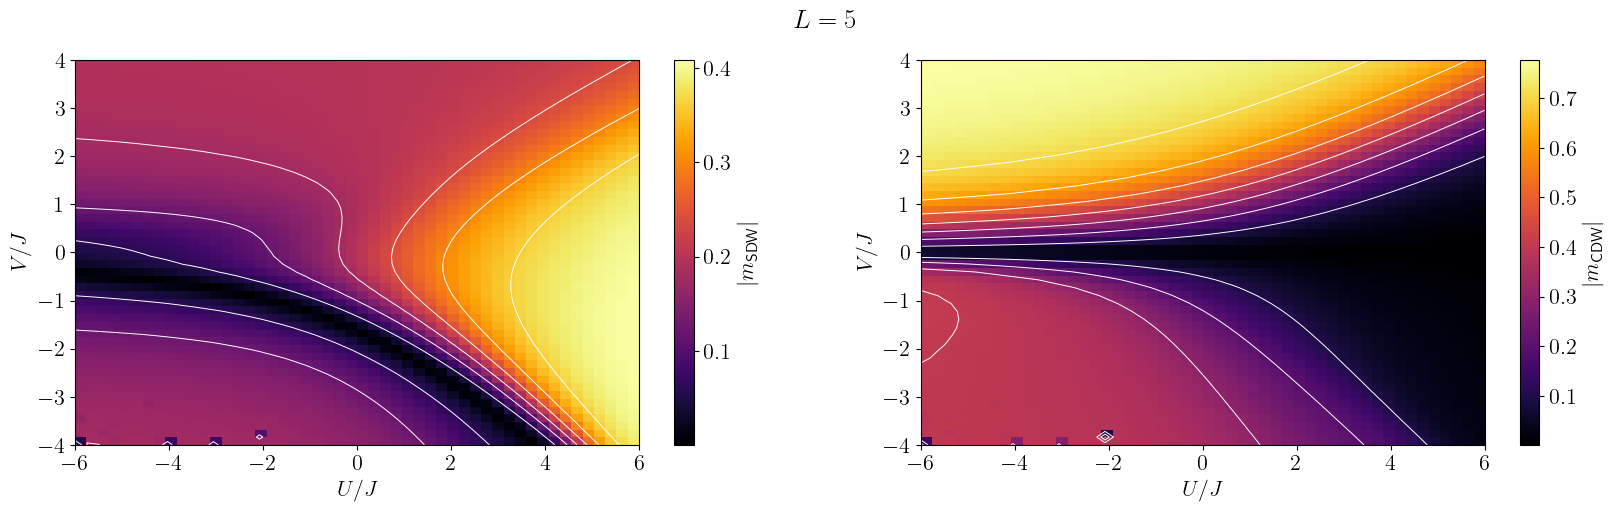

In [69]:
# magnetization, charge_density, _, _, _, _, _, U_vals, V_vals = load_data(L, U_max, V_max, N_Points, min_vals=False)

m_sdw = np.zeros((N_Points, N_Points))
m_cdw = np.zeros((N_Points, N_Points))

for i, U in enumerate(U_vals):
    for j, V in enumerate(V_vals):

        magnetization_ij = magnetization[i, j]
        charge_density_ij = charge_density[i, j]

        m_sdw[i, j] = np.abs(m_SDW(L, magnetization_ij))
        m_cdw[i, j] = np.abs(m_CDW(L, charge_density_ij))

# The data in m_sdw and m_cdw are transposed!
m_sdw = m_sdw.T 
m_cdw = m_cdw.T

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(20, 5), sharex=True)
plt.suptitle(f"$L = {L}$")

# Plot m_SDW heatmap
im0 = ax[0].imshow(m_sdw, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="inferno")
fig.colorbar(im0, ax=ax[0], label=r"$|m_{\text{SDW}}|$")

X, Y = np.meshgrid(U_vals, V_vals)
ax[0].contour(X, Y, m_sdw, colors='white', linestyle='--', linewidths=0.7)

ax[0].set_xlabel(r"$U / J$")
ax[0].set_ylabel(r"$V / J$")
#ax[0].set_title(r"$m_{\text{SDW}}=(1/L) \sum_{j}(-1)^j \langle \hat{S}_{j}^{z} \rangle$")

# Plot m_CDW heatmap
im1 = ax[1].imshow(m_cdw, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="inferno")
fig.colorbar(im1, ax=ax[1] , label=r"$|m_{\text{CDW}}|$")

X, Y = np.meshgrid(U_vals, V_vals)
ax[1].contour(X, Y, m_cdw, colors='white', linestyle='--', linewidths=0.7)

ax[1].set_xlabel(r"$U / J$")
ax[1].set_ylabel(r"$V / J$")

#ax[1].set_title(r"$m_{\text{CDW}}=(1/L)\sum_{j}(-1)^j (\langle \hat{n}_j \rangle-1)$")

# Plot line U = 2V
# V_range = np.linspace(0, U_max / 2, N_Points)
# U_range = 2 * V_range 
# ax[0].plot(U_range, V_range, 'w--', linewidth=1)
# ax[1].plot(U_range, V_range, 'w--', linewidth=1)

# Save the figure
plt.savefig(f"{figures_path}/{model}_{exec}/order_parameters_L={L}_Npoints={N_Points}_Umax={U_max}_Vmax={V_max}.png", dpi=300, bbox_inches="tight")
plt.show()

- Energy


/tmp/ipykernel_49598/2265092902.py:11: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ax.contour(X, Y, energy, colors='white', linestyle='--', linewidths=0.7)


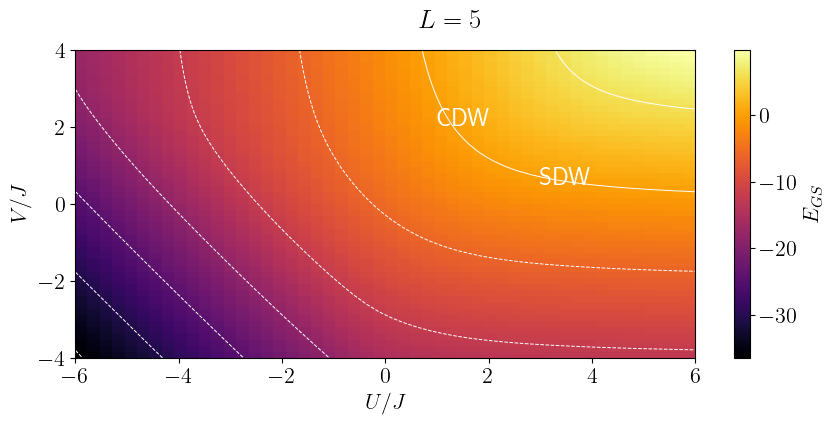

In [70]:
# _, _, _, energy, _, _, _, U_vals, V_vals = load_data(L, U_max, V_max, N_Points)
# Create a figure with two subplots
fig, ax = plt.subplots(1, 1, figsize=(10, 4), sharex=True)
    
im0 = ax.imshow(energy, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="inferno")
fig.colorbar(im0, ax=ax, label=r"$E_{GS}$")
ax.set_xlabel(r"$U / J$")
ax.set_ylabel(r"$V / J$")

X, Y = np.meshgrid(U_vals, V_vals)
ax.contour(X, Y, energy, colors='white', linestyle='--', linewidths=0.7)

# Plot line U = 2V
# V_range = np.linspace(0, U_max / 2, N_Points)
# U_range = 2 * V_range 
# ax.plot(U_range, V_range, 'w--', linewidth=1)  
    
ax.text(1, 2, "$\\text{CDW}$", color = "white", fontsize=18)
ax.text(3, 0.5, "$\\text{SDW}$", color = "white", fontsize=18)
    
plt.suptitle(f"$L = {L}$")
plt.show()
fig.savefig(f"{figures_path}/{model}_{exec}/E_GS={L}_{model}_NPoints={N_Points}.png", dpi = 500, bbox_inches='tight')


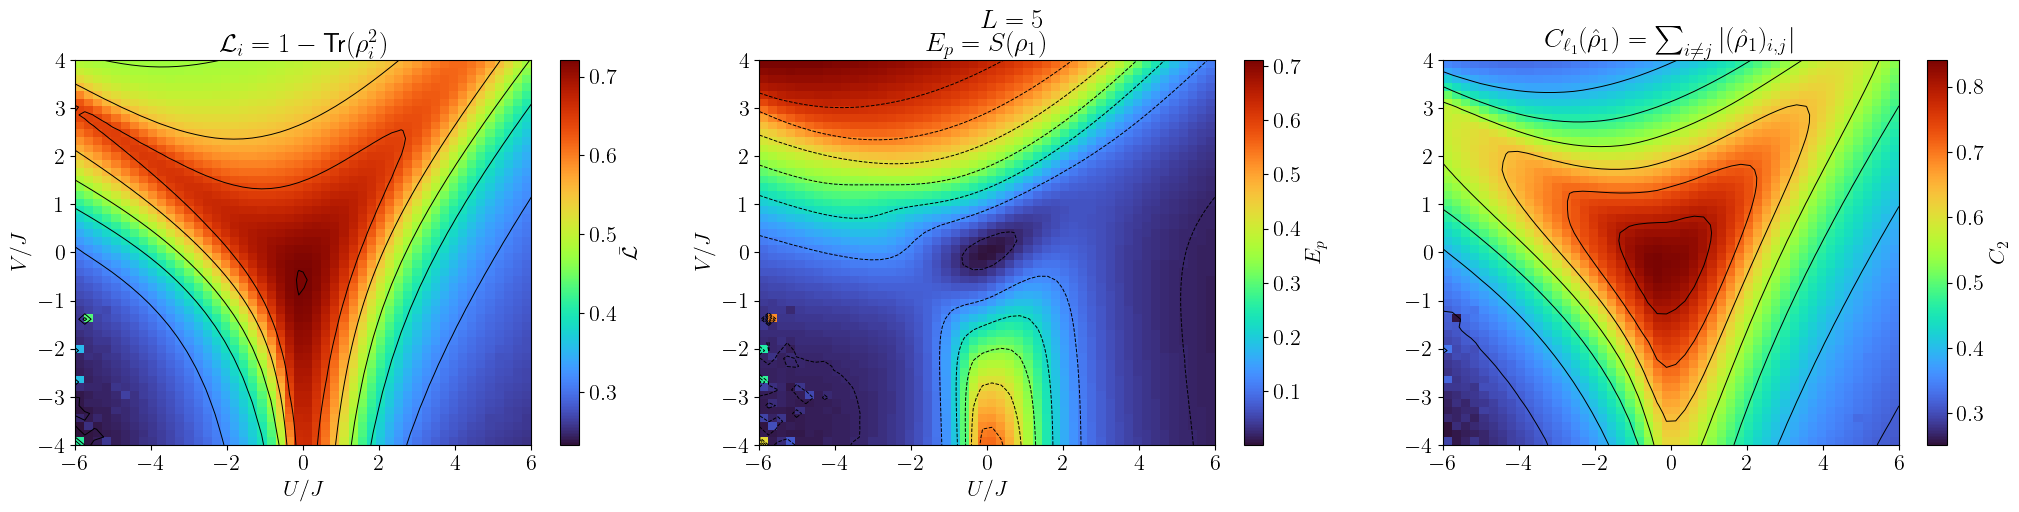

In [71]:
# _, _, _ , _, E_p, avg_linear_entropy,  U_vals, V_vals = load_data(L, U_max, V_max, N_Points)

# Create a figure with two subplots
fig, ax1 = plt.subplots(1, 3, figsize=(25, 5))
plt.suptitle(f"$L = {L}$")

# Shared colorbar normalization - thanks chatgpt
# vmin = min(np.min(avg_linear_entropy), np.min(E_p))
# vmax = max(np.max(avg_linear_entropy), np.max(E_p))

U_min = -U_max 
V_min = -V_max

# E_p = E_p / np.max(E_p) 
# avg_linear_entropy = avg_linear_entropy / np.max(avg_linear_entropy)

# Contour 
X, Y = np.meshgrid(U_vals, V_vals)

im0 = ax1[0].imshow(avg_linear_entropy, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="turbo")# , vmin=vmin, vmax=vmax)
fig.colorbar(im0, ax = ax1[0], orientation='vertical', label=r"$\bar{\mathcal{L}}$") # /\text{max}(\bar{\mathcal{L}})$")

ax1[0].contour(X, Y, avg_linear_entropy, colors='black', linewidths=0.7)


im1 = ax1[1].imshow(E_p + np.log2(L), origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="turbo") #  , vmin=vmin, vmax=vmax)
fig.colorbar(im1, ax = ax1[1], orientation='vertical',  label=r"$E_p$") #  / \text{max}(E_{p})$")
ax1[1].contour(X, Y, E_p, colors='black', linewidths=0.7)


im2 = ax1[2].imshow(quantum_coh, origin="lower", extent=[U_min, U_max, V_min, V_max], aspect="auto", cmap="turbo") #  , vmin=vmin, vmax=vmax)
fig.colorbar(im2, ax = ax1[2], orientation='vertical',  label=r"$C_2$")
ax1[2].contour(X, Y, quantum_coh, colors='black', linewidths=0.7)
1
# bar = plt.colorbar(im0, orientation='vertical', shrink=0.8, label=r"$E_p$") 
ax1[0].set_xlabel(r"$U / J$")
ax1[0].set_ylabel(r"$V / J$")

ax1[1].set_xlabel(r"$U / J$")
ax1[1].set_ylabel(r"$V / J$")

ax1[0].set_title(r"$\mathcal{L}_i = 1 - \text{Tr}(\rho_i^2)$")
ax1[1].set_title(r"$E_p = S(\rho_1)$")
ax1[2].set_title(r"$C_{\ell_1}(\hat{\rho}_1) = \sum_{i\neq j}|(\hat{\rho}_1)_{i, j}|$")

# ax1[0].hlines(0, 0, -6.0, colors="white", linestyles='solid')
# ax1[1].hlines(0, 0, -6.0, colors="white", linestyles='solid')
## Plot line U = 2V
# V_range = np.linspace(0, U_max / 2, N_Points)
# U_range = 2 * V_range 
# ax1[0].plot(U_range, V_range, 'w', linewidth=1)
# ax1[1].plot(U_range, V_range, 'w', linewidth=1)
# ax1[0].plot(U_range, -V_range, 'w', linewidth=1)
# ax1[1].plot(U_range, -V_range, 'w', linewidth=1)
# ax1[2].plot(U_range, -V_range, 'w', linewidth=1# )
# ax1[0].text(-4, 2, "CDW random_MPS", fontweight='bold', color = "white", fontsize=18)
# ax1[0].text(2, 0, "SDW random_MPS", fontweight='bold', color = "white", fontsize=18)
# ax1[1].text(-4, 2, "CDW random_MPS", fontweight='bold', color = "white", fontsize=18)
# ax1[1].text(2, 0, "SDW random_MPS", fontweight='bold', color = "white", fontsize=18)

fig.savefig(f"{figures_path}/{model}_{exec}/entanglement_entropy_1_RDM_L={L}_NPoints={N_Points}.png", dpi=100, bbox_inches='tight')
plt.show()